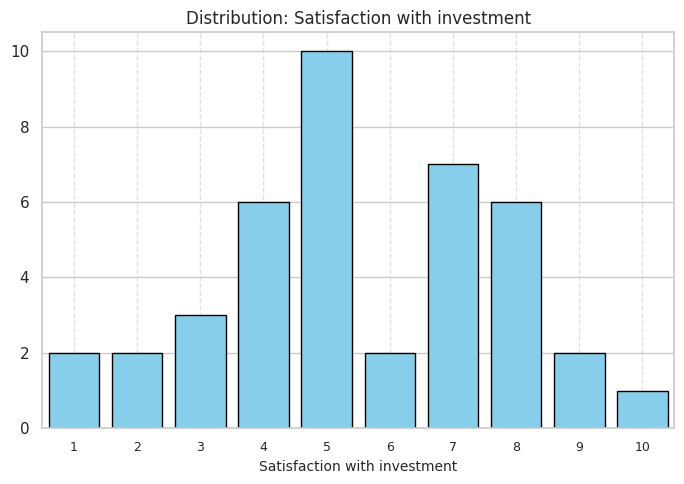

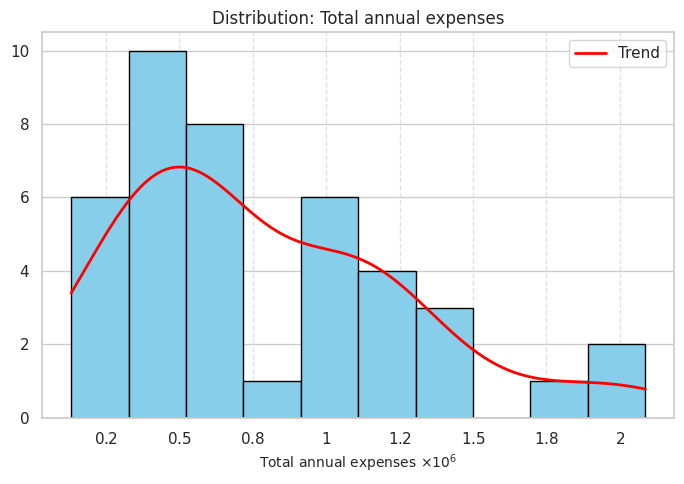

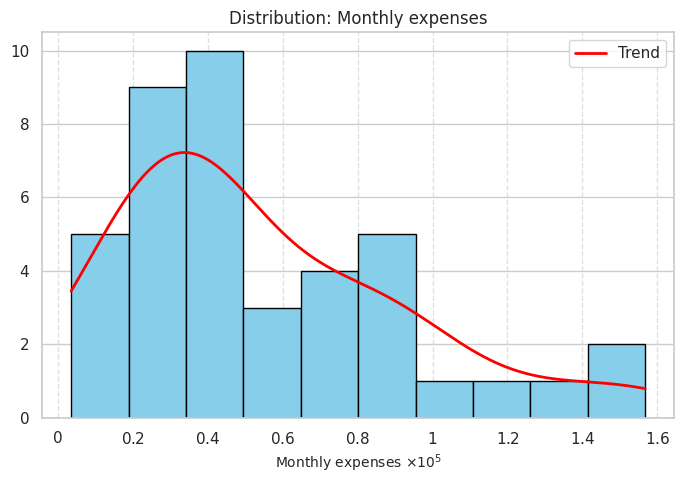

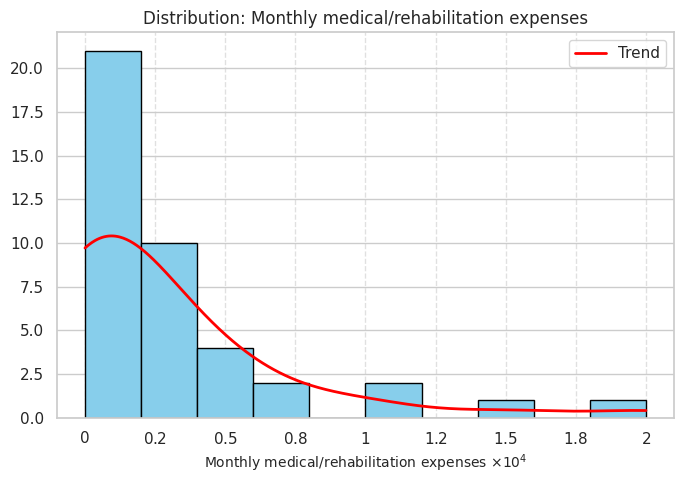

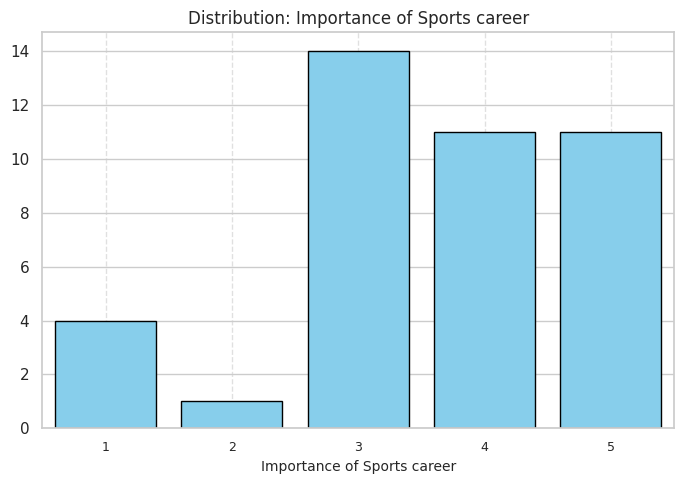

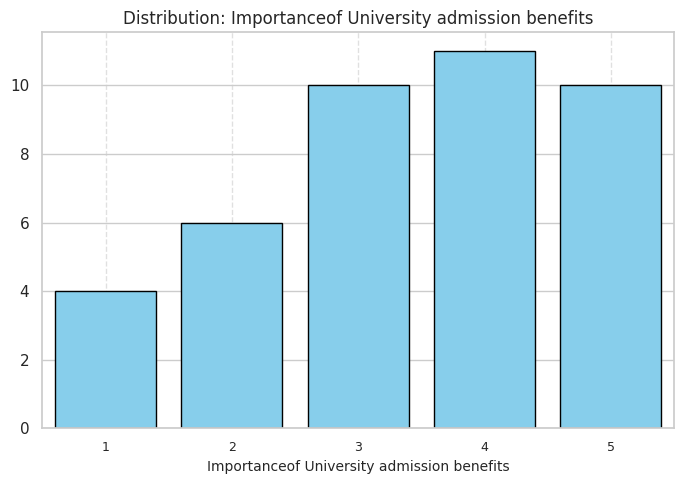

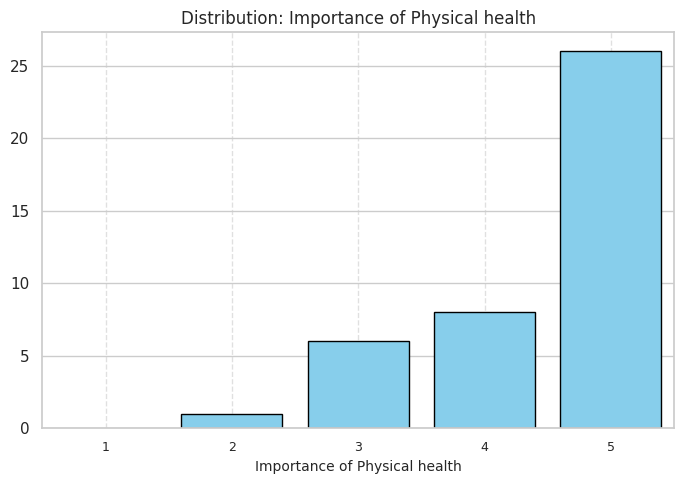

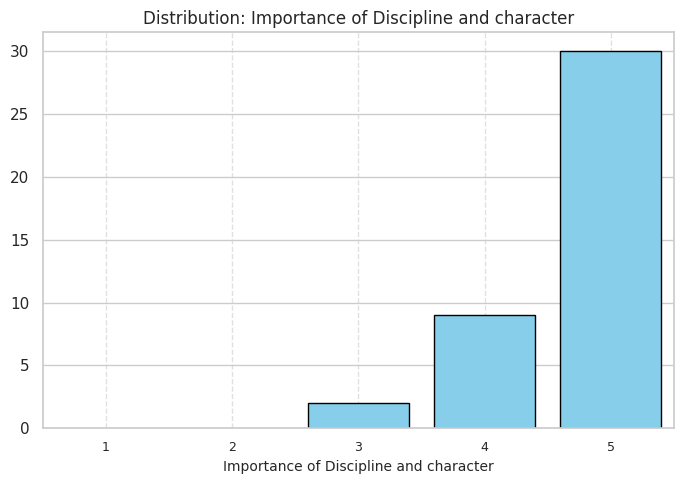

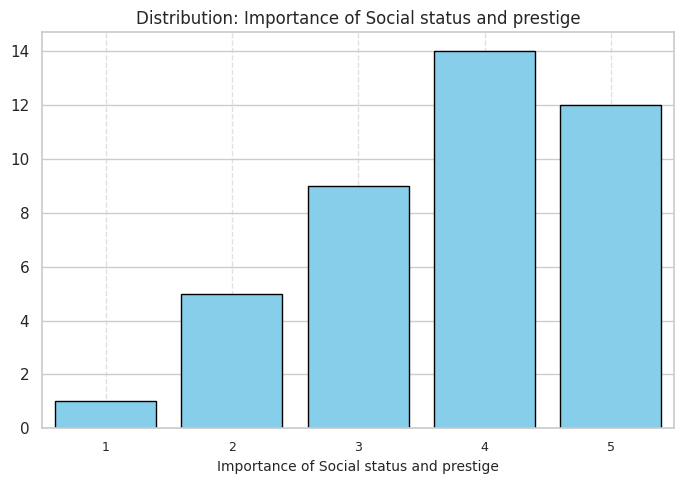

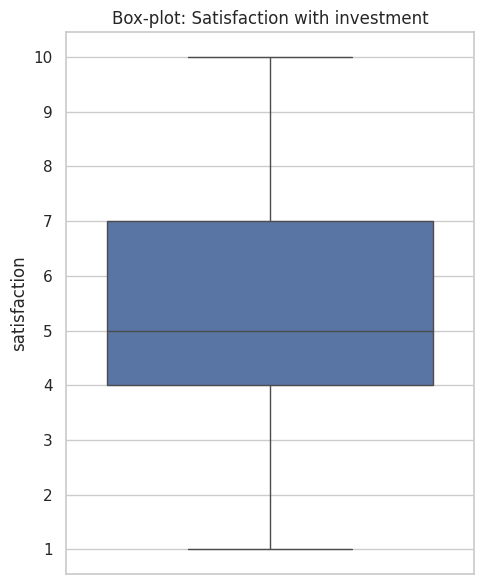

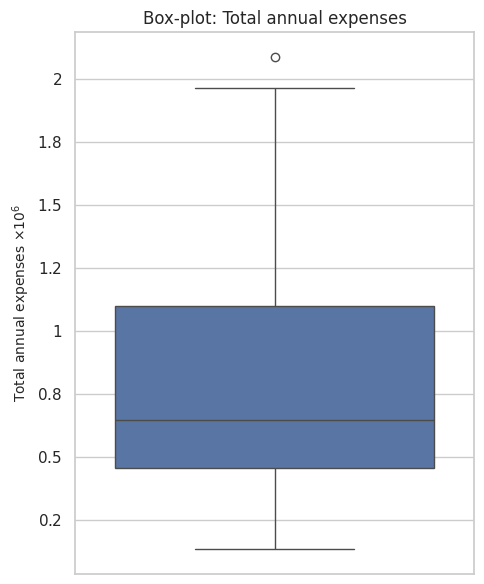

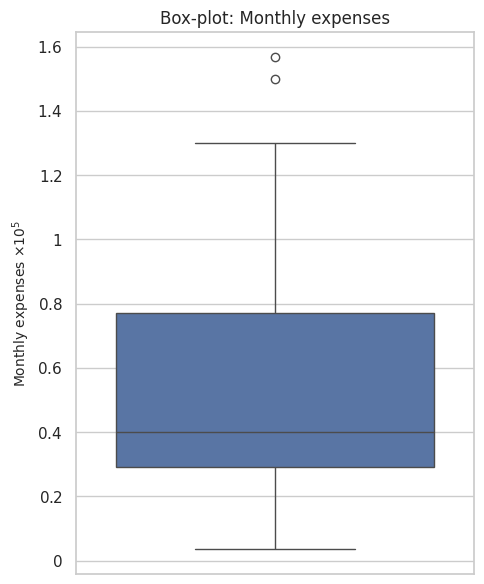

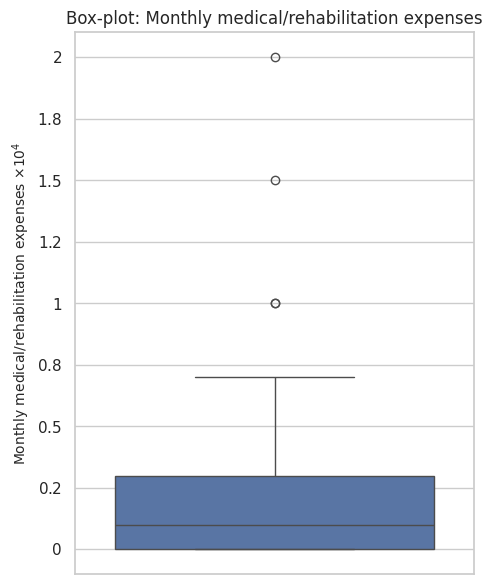

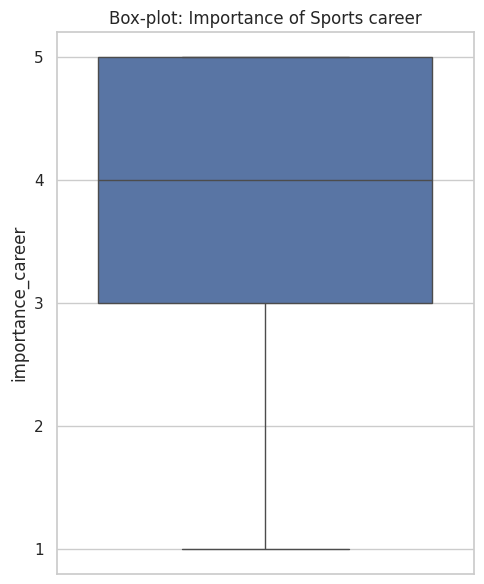

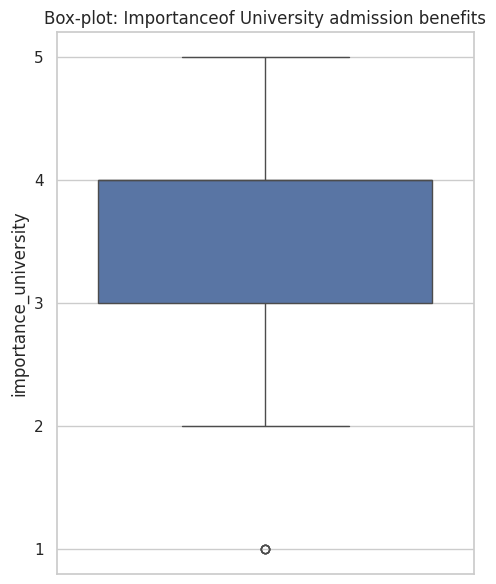

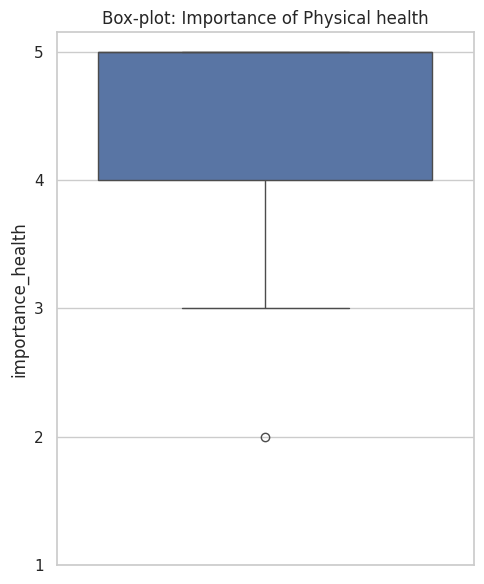

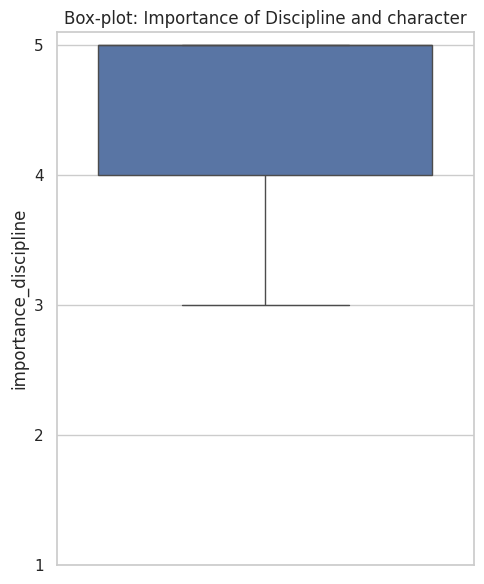

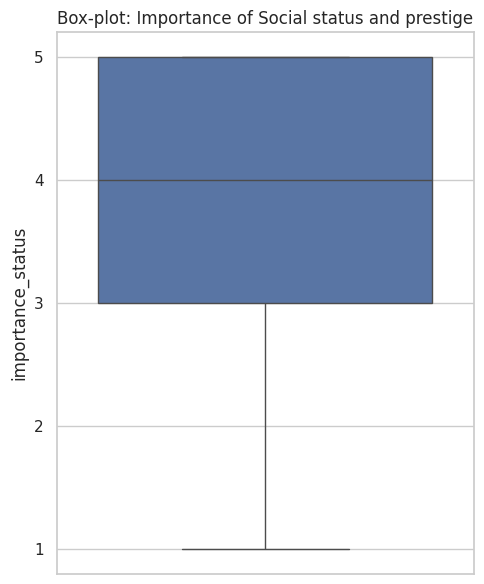

In [ ]:
#графики количественных и категориальных переменных(которые преобразуются в числовые)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import FuncFormatter
import numpy as np
from scipy.stats import gaussian_kde

# Загрузка данных
file_path = "/content/Данные_курсовая.xlsx"
df = pd.read_excel(file_path)

# Настройка стиля
sns.set(style="whitegrid")

# Переименование колонок
df = df.rename(columns={
    'Что из нижеперечисленного лучше всего описывает финансовое положение вашей семьи: ': 'income',
    "Медицина/реабилитация:": 'medicine',
    "Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?": 'percentage',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): Профессиональная спортивная карьера": 'importance_career',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nЛьготы при поступлении в вуз": 'importance_university',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nФизическое развитие и здоровье": 'importance_health',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nРазвитие дисциплины и характера": 'importance_discipline',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nСоциальный статус и престиж": 'importance_status',
    "Насколько вы удовлетворены отдачей от финансовых вложений в спорт? Оцените по шкале от 1 – совсем не удовлетворен(а) до 10 – полностью удовлетворен(а). ": 'satisfaction',
    "Возраст спортсмена:": 'age',
    "Стаж занятий(количество лет занятий художественной гимнастикой):": 'experience',
    "Уровень подготовки ": 'level',
    "Место занятий": 'place',
    "Спортивный разряд": 'sport_class',
    " Достижения спортсмена за последние 2 года:": 'achievements',
    "Получал ли спортсмен доход от спорта?": 'earnings',
    "Выплаты от сборной: ": 'team_money',
    "Стипендии:": 'scholarship',
    "Спонсорская поддержка:": 'sponsor',
    "Выплаты за участие в рекламе(связанной со спортом): ": 'advertising',
    " Доход от работы/подработки тренером/хореографом и т.д.": 'job',
    "Общие ежемесячные расходы": 'month_full',
    "Общие ежегодные расходы": 'year_full',
    "Сумма расходов в год": 'sum_year',
    "Состоит ли спортсмен в сборной?": 'team_yesno',
    "Были ли случаи прекращения занятий?": 'pause_yesno',
    "Прекратил ли спортсмен занятия?": 'theend_yesno'
})

# Словарь читаемых названий переменных
variable_names = {
    'satisfaction': 'Satisfaction with investment',
    'sum_year': 'Total annual expenses',
    'month_full': 'Monthly expenses',
    'medicine': 'Monthly medical/rehabilitation expenses',
    'importance_career': 'Importance of Sports career',
    'importance_university': 'Importanceof University admission benefits',
    'importance_health': 'Importance of Physical health',
    'importance_discipline': 'Importance of Discipline and character',
    'importance_status': 'Importance of Social status and prestige'
}

# Приведение к числовому типу
quant_cols = list(variable_names.keys())
for col in quant_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Папка для сохранения графиков
os.makedirs("graphs", exist_ok=True)

# Форматирование осей
def fixed_exponent_formatter_factory(exponent, base=10):
    def formatter(x, _):
        if x == 0:
            return "0"
        coeff = x / (base ** exponent)
        if abs(coeff - round(coeff)) < 1e-9:
            return f"${round(coeff):.0f}$"
        else:
            return f"${coeff:.1f}$"
    return formatter, f"$\\times 10^{exponent}$"

# Гистограммы
for col in quant_cols:
    plt.figure(figsize=(7, 5))
    data = df[col].dropna().astype(float)

    if data.empty:
        print(f"Warning: Column '{col}' is empty after dropping NaNs. Skipping histogram.")
        plt.close()
        continue

    ax = plt.gca()

    # Гистограммы для шкальных переменных
    if col in ['satisfaction', 'importance_career', 'importance_university',
               'importance_health', 'importance_discipline', 'importance_status']:

        counts = data.value_counts().sort_index()
        x_vals = counts.index.astype(float)
        y_vals = counts.values

        ax.bar(x_vals, y_vals, width=0.8, color='skyblue', edgecolor='black')

        if col == 'satisfaction':
            ax.set_xticks(np.arange(1, 11, 1))
            ax.set_xlim(0.5, 10.5)
        else:
            ax.set_xticks(np.arange(1, 6, 1))
            ax.set_xlim(0.5, 5.5)

        ax.set_xticklabels(ax.get_xticks(), fontsize=9)
        plt.xlabel(variable_names.get(col, col), fontsize=10)

    # Гистограммы для непрерывных переменных
    else:
        bins = 10
        counts, bin_edges = np.histogram(data, bins=bins)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width = bin_edges[1] - bin_edges[0]

        ax.bar(bin_centers, counts, width=bin_width, color='skyblue', edgecolor='black')

        if len(data) > 1:
            try:
                kde = gaussian_kde(data)
                x_vals = np.linspace(data.min(), data.max(), 500)
                y_vals = kde(x_vals) * len(data) * bin_width
                ax.plot(x_vals, y_vals, color='red', lw=2, label='Trend')
                plt.legend()
            except np.linalg.LinAlgError:
                print(f"Warning: Could not compute KDE for column '{col}'.")

        if data.max() > 0:
            fixed_exponent = int(np.floor(np.log10(data.max())))
            formatter, exponent_label = fixed_exponent_formatter_factory(fixed_exponent)
            ax.xaxis.set_major_formatter(formatter)
            plt.xlabel(f"{variable_names.get(col, col)} {exponent_label}", fontsize=10)

    plt.title(f"Distribution: {variable_names.get(col, col)}", fontsize=12)
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"graphs/hist_trend_{col}.png")
    plt.show()

# Boxplots
for col in quant_cols:
    plt.figure(figsize=(5, 6))
    data = df[col].dropna().astype(float)

    if data.empty:
        print(f"Warning: Column '{col}' is empty after dropping NaNs. Skipping box-plot.")
        plt.close()
        continue

    sns.boxplot(y=data)
    plt.title(f"Box-plot: {variable_names.get(col, col)}", fontsize=12)

    if col == 'satisfaction':
        plt.yticks(np.arange(1, 11, 1))
    elif col in ['importance_career', 'importance_university', 'importance_health',
                 'importance_discipline', 'importance_status']:
        plt.yticks(np.arange(1, 6, 1))
    else:
        if data.max() > 0:
            fixed_exponent = int(np.floor(np.log10(data.max())))
            formatter, exponent_label = fixed_exponent_formatter_factory(fixed_exponent)
            plt.gca().yaxis.set_major_formatter(formatter)
            plt.ylabel(f"{variable_names.get(col, col)} {exponent_label}", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"graphs/box_{col}.png")
    plt.show()


In [ ]:
import shutil
shutil.make_archive('all_graphs', 'zip', 'graphs')
from google.colab import files
files.download("all_graphs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

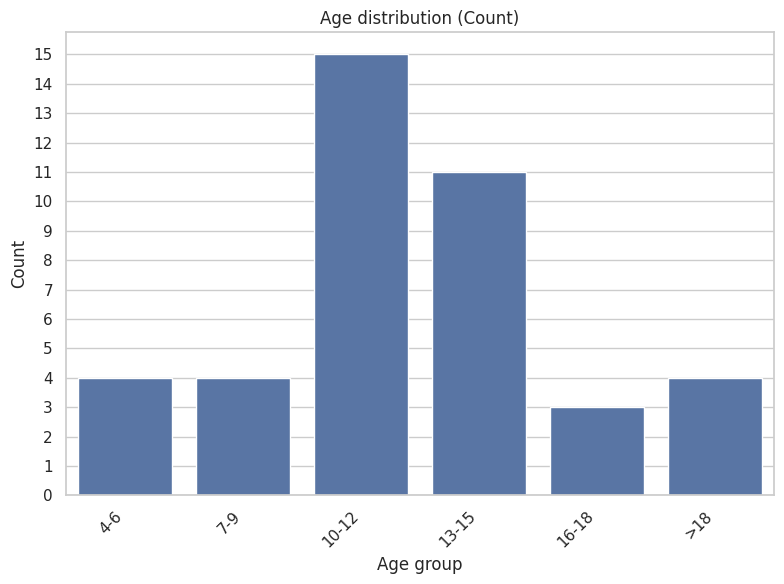

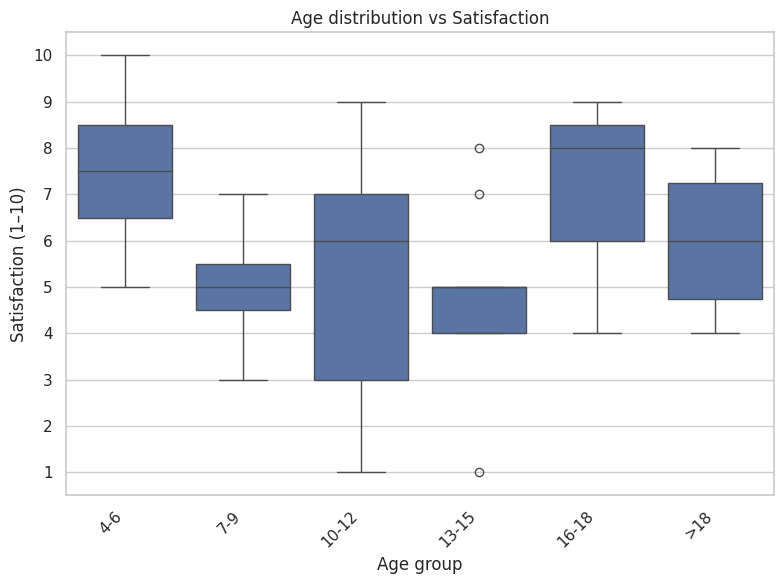

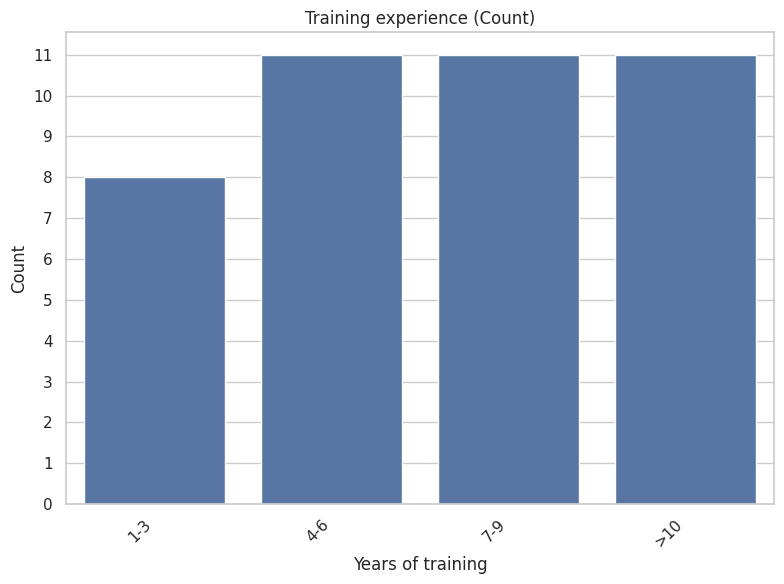

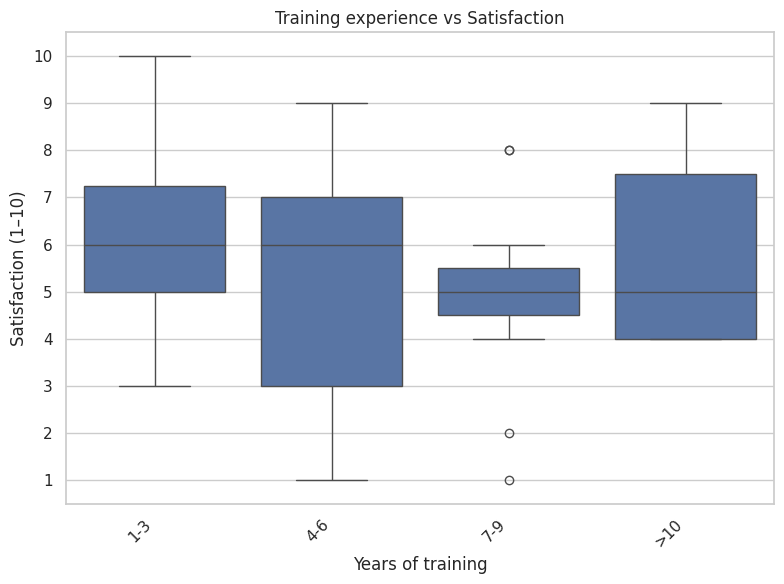

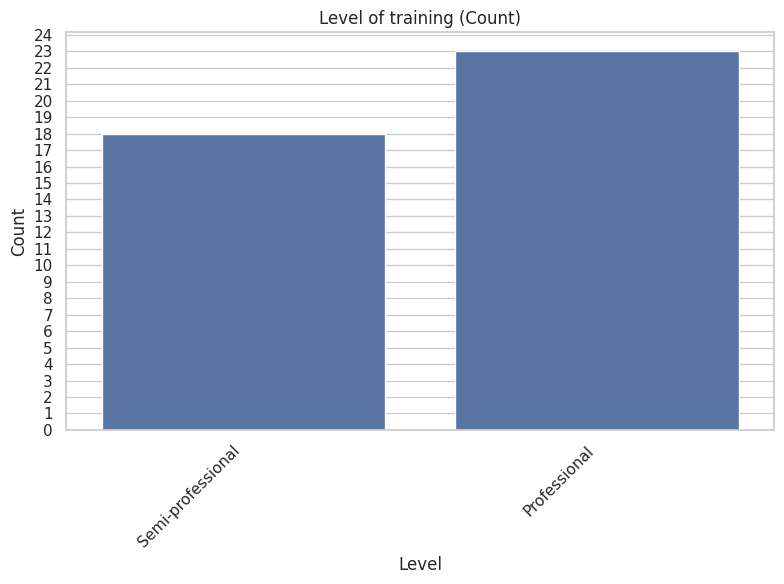

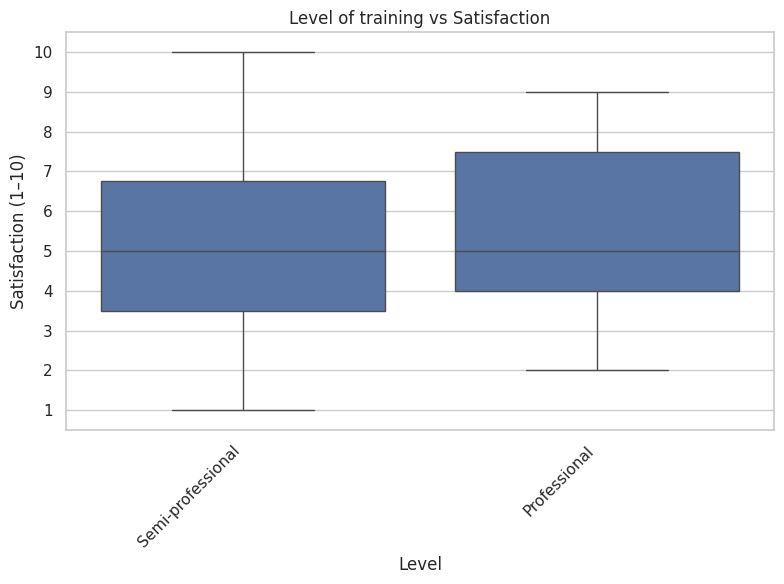

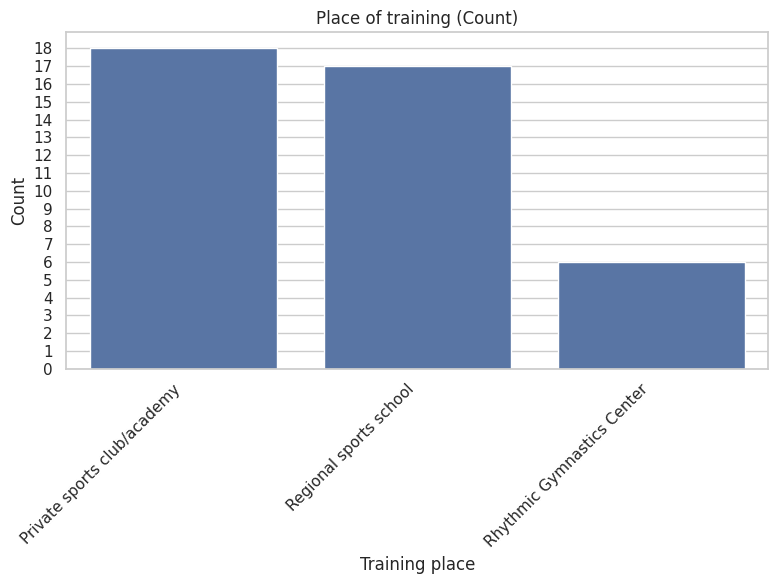

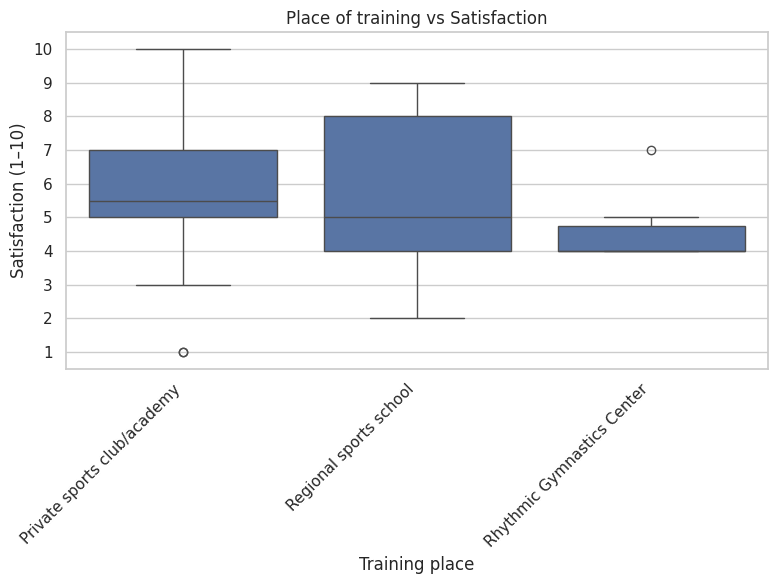

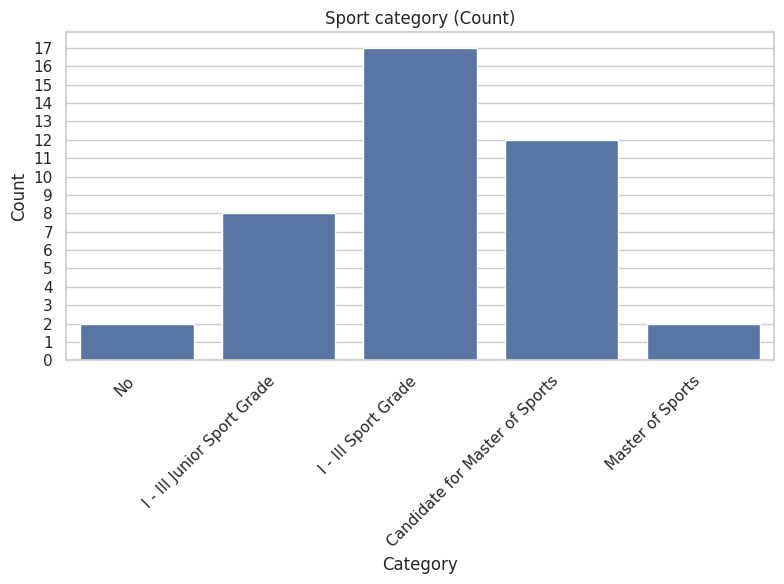

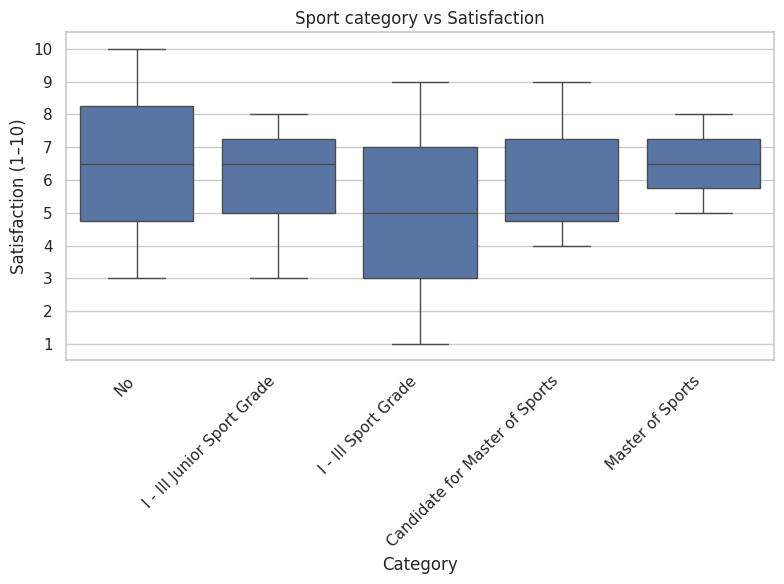

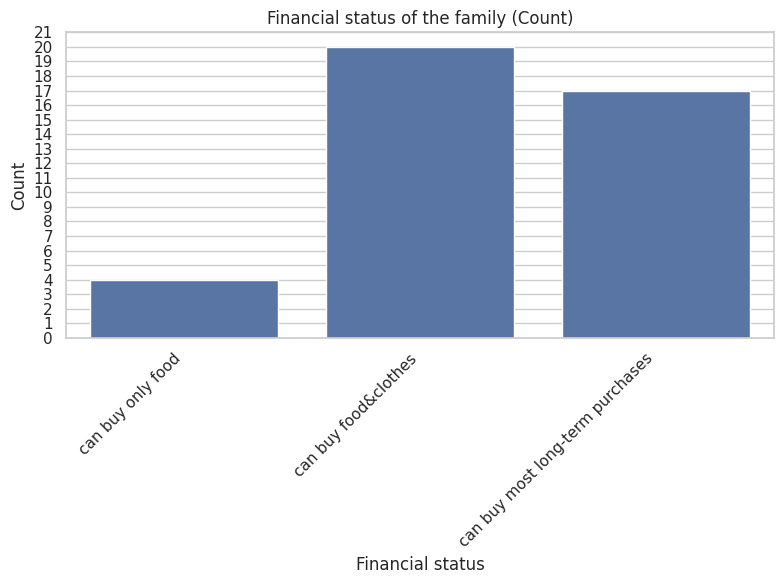

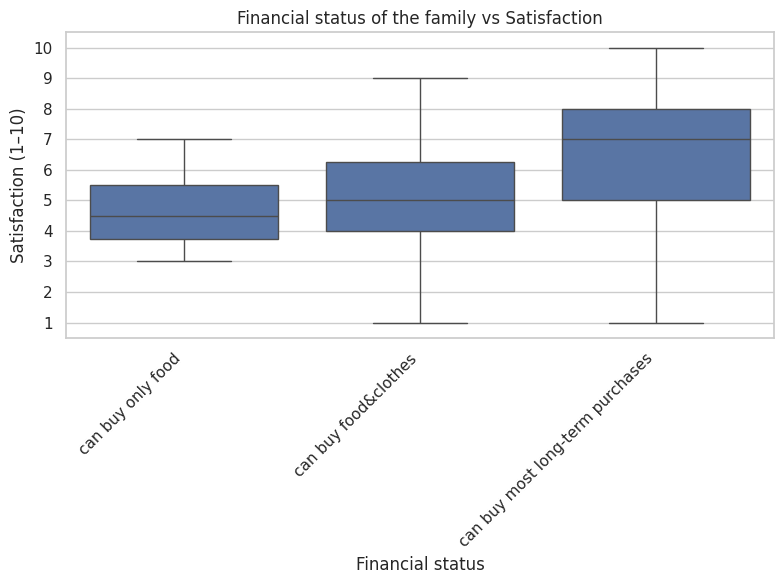

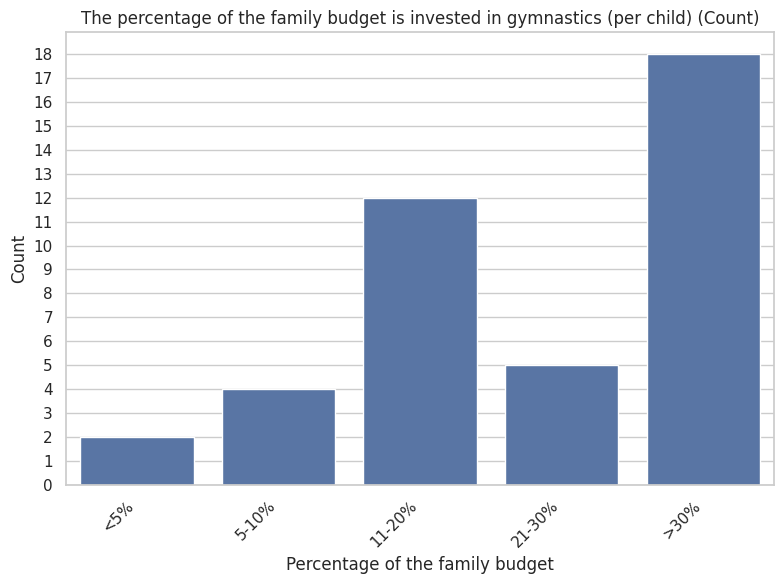

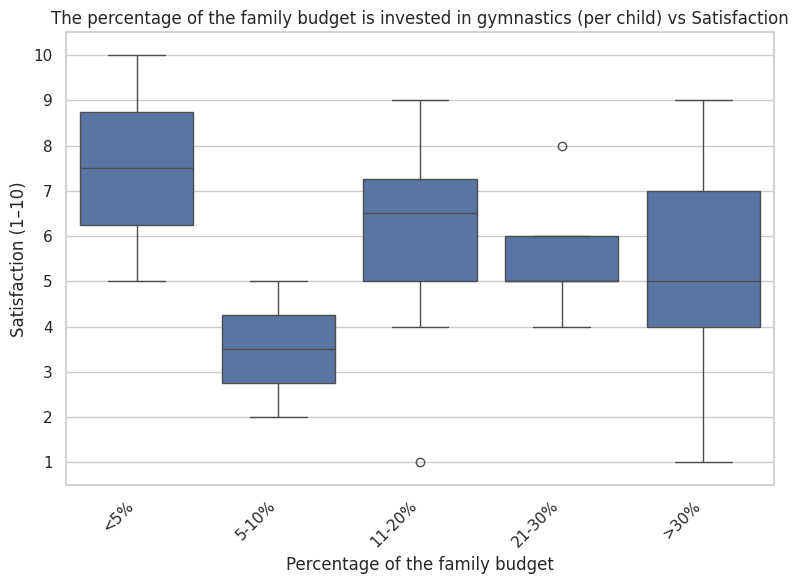

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Графики категориальных переменных
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

import os
import shutil

# Создание папки для графиков
graph_dir = 'graphs_categorical'
os.makedirs(graph_dir, exist_ok=True)

# Настройки визуализации
sns.set(style='whitegrid')
plt.rcParams['axes.unicode_minus'] = False

# Загрузка данных
data = pd.read_excel('Данные_курсовая.xlsx', sheet_name='Ответы на форму (1)')

# Переименование столбцов
column_mapping = {
    'Что из нижеперечисленного лучше всего описывает финансовое положение вашей семьи: ': 'income',
    'Медицина/реабилитация:': 'medicine',
    'Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?': 'percentage',
    'Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): Профессиональная спортивная карьера': 'importance_career',
    'Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nЛьготы при поступлении в вуз': 'importance_university',
    'Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nФизическое развитие и здоровье': 'importance_health',
    'Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nРазвитие дисциплины и характера': 'importance_discipline',
    'Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nСоциальный статус и престиж': 'importance_status',
    'Насколько вы удовлетворены отдачей от финансовых вложений в спорт? Оцените по шкале от 1 – совсем не удовлетворен(а) до 10 – полностью удовлетворен(а). ': 'satisfaction',
    'Возраст спортсмена:': 'age',
    'Стаж занятий(количество лет занятий художественной гимнастикой):': 'experience',
    'Уровень подготовки ': 'level',
    'Место занятий': 'place',
    'Спортивный разряд': 'sport_class',
    'Достижения спортсмена за последние 2 года:': 'achievements',
    'Получал ли спортсмен доход от спорта?': 'earnings',
    'Выплаты от сборной: ': 'team_money',
    'Стипендии:': 'scholarship',
    'Спонсорская поддержка:': 'sponsor',
    'Выплаты за участие в рекламе(связанной со спортом): ': 'advertising',
    'Доход от работы/подработки тренером/хореографом и т.д.': 'job',
    'Общие ежемесячные расходы': 'month_full',
    'Общие ежегодные расходы': 'year_full',
    'Сумма расходов в год': 'sum_year',
    'Состоит ли спортсмен в сборной?': 'team_yesno',
    'Были ли случаи прекращения занятий?': 'pause_yesno',
    'Прекратил ли спортсмен занятия?': 'theend_yesno'
}
data = data.rename(columns=column_mapping)

# ===== ЗАМЕНА КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ =====

# Возраст
age_labels = {
    '4-6 лет': '4-6',
    '7-9 лет': '7-9',
    '10-12 лет': '10-12',
    '13-15 лет': '13-15',
    '16 - 18 лет': '16-18',
    'больше 18 лет': '>18'
}
age_order = ['4-6', '7-9', '10-12', '13-15', '16-18', '>18']
data['age_clean'] = pd.Categorical(data['age'].map(age_labels), categories=age_order, ordered=True)

# Стаж
experience_labels = {
    '1-3 года': '1-3',
    '4-6 лет': '4-6',
    '7-9 лет': '7-9',
    '>10 лет': '>10'
}
experience_order = ['1-3', '4-6', '7-9', '>10']
data['experience_clean'] = pd.Categorical(data['experience'].map(experience_labels), categories=experience_order, ordered=True)

# Доход
income_labels = {
    'У нас хватает денег только на еду': 'can buy only food',
    'Мы можем позволить себе еду и одежду, но на более крупные вещи нам приходится экономить': 'can buy food&clothes',
    'Большинство долгосрочных покупок (холодильник, телевизор) - не проблема, но мы не можем позволить себе купить квартиру': 'can buy most long-term purchases'
}
income_order = ['can buy only food', 'can buy food&clothes', 'can buy most long-term purchases']
data['income_clean'] = pd.Categorical(data['income'].map(income_labels), categories=income_order, ordered=True)

#Процент
percentage_labels = {
    '<5%': '<5%',
    '5-10%': '5-10%',
    '11-20%': '11-20%',
    '21-30%' : '21-30%',
    '>30%' : '>30%'
}
percentage_order = ['<5%', '5-10%', '11-20%', '21-30%','>30%' ]
data['percentage_clean'] = pd.Categorical(data['percentage'].map(percentage_labels), categories=percentage_order, ordered=True)

# Уровень подготовки
level_labels = {
    'Полупрофессиональный (участие в местных и городских соревнованиях)': 'Semi-professional',
    'Профессиональный (подготовка к соревнованиям всероссийского и высокого уровня)': 'Professional'
}
level_order = ['Semi-professional', 'Professional']
data['level_clean'] = pd.Categorical(data['level'].map(level_labels), categories=level_order, ordered=True)

# Место
place_labels = {
    'Частный клуб/академия': 'Private sports club/academy',
    'Районная спортивная школа': 'Regional sports school',
    'Специализированный центр(Например, ЦХГ “Жемчужина”)': 'Rhythmic Gymnastics Center'
}
place_order = ['Private sports club/academy', 'Regional sports school', 'Rhythmic Gymnastics Center']
data['place_clean'] = pd.Categorical(data['place'].map(place_labels), categories=place_order, ordered=True)

# Разряд
sport_class_labels = {
    'Нет': 'No',
    'I - III Юношеский': 'I - III Junior Sport Grade',
    'I - III Спортивный(Взрослый)': 'I - III Sport Grade',
    'КМС (кандидат в мастера спорта)': 'Candidate for Master of Sports',
    'МС (мастер спорта)': 'Master of Sports'
}
sport_class_order = ['No', 'I - III Junior Sport Grade', 'I - III Sport Grade', 'Candidate for Master of Sports', 'Master of Sports']
data['sport_class_clean'] = pd.Categorical(data['sport_class'].map(sport_class_labels), categories=sport_class_order, ordered=True)

# ===== ФУНКЦИЯ ДЛЯ ВИЗУАЛИЗАЦИИ =====
def set_integer_ticks_force(ax):
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

def plot_count_and_box(column, title, xlabel, order):
    # Countplot
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=data, x=column, order=order)
    set_integer_ticks_force(ax) # <-- Вызываем функцию для установки делений по 1
    plt.title(f'{title} (Count)')
    plt.xlabel(xlabel)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Boxplot по переменной satisfaction (ось Y здесь числовая, не Count)
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=data, x=column, y='satisfaction', order=order)
    # Для boxplot оси Y с удовлетворенностью (1-10) можно тоже настроить метки
    # Например, если нужно показать все целые от 1 до 10
    ax_box = plt.gca()
    ax_box.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax_box.set_ylim(0.5, 10.5) # Опционально: установить границы оси Y для диапазона 1-10

    plt.title(f'{title} vs Satisfaction')
    plt.xlabel(xlabel)
    plt.ylabel('Satisfaction (1–10)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



# ===== ВЫЗОВ ГРАФИКОВ =====

plot_count_and_box('age_clean', 'Age distribution', 'Age group', age_order)
plot_count_and_box('experience_clean', 'Training experience', 'Years of training', experience_order)
plot_count_and_box('level_clean', 'Level of training', 'Level', level_order)
plot_count_and_box('place_clean', 'Place of training', 'Training place', place_order)
plot_count_and_box('sport_class_clean', 'Sport category', 'Category', sport_class_order)
plot_count_and_box('income_clean', 'Financial status of the family', 'Financial status', income_order)
plot_count_and_box('percentage_clean', 'The percentage of the family budget is invested in gymnastics (per child)', 'Percentage of the family budget', percentage_order)

# Упаковка в архив
shutil.make_archive('categorical_graphs', 'zip', graph_dir)

# Только для Google Colab:
try:
    from google.colab import files
    files.download('categorical_graphs.zip')
except:
    print("Файл categorical_graphs.zip создан в текущей директории.")



In [ ]:
import shutil
shutil.make_archive('categorical_graphs', 'zip', 'graphs')
from google.colab import files
files.download("categorical_graphs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Описательная статистика
import pandas as pd

# Путь к файлу
file_path = '/content/Данные_курсовая.xlsx'

# Загрузка Excel-файла
xls = pd.ExcelFile(file_path)

# Загрузка нужного листа
df = pd.read_excel(xls, sheet_name='Ответы на форму (1)')

# Переименование столбцов
rename_dict = {
    "Что из нижеперечисленного лучше всего описывает финансовое положение вашей семьи: ": "income",
    "Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?": "percentage",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): Профессиональная спортивная карьера": "importance_career",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nЛьготы при поступлении в вуз": "importance_university",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nФизическое развитие и здоровье": "importance_health",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nРазвитие дисциплины и характера": "importance_discipline",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nСоциальный статус и престиж": "importance_status",
    "Насколько вы удовлетворены отдачей от финансовых вложений в спорт? Оцените по шкале от 1 – совсем не удовлетворен(а) до 10 – полностью удовлетворен(а). ": "satisfaction",
    "Возраст спортсмена:": "age",
    "Стаж занятий(количество лет занятий художественной гимнастикой):": "experience",
    "Общие ежемесячные расходы": "month_full",
    "Общие ежегодные расходы": "year_full",
    "Сумма расходов в год": "sum_year"
}
df.rename(columns=rename_dict, inplace=True)


# Перечень числовых переменных
numeric_vars = [
    'satisfaction', 'month_full', 'year_full', 'sum_year',
    'importance_career', 'importance_university', 'importance_health',
    'importance_discipline', 'importance_status'
]

# Приведение к числовому типу
df[numeric_vars] = df[numeric_vars].apply(pd.to_numeric, errors='coerce')

# Расчёт описательной статистики
desc_stats = df[numeric_vars].describe().T
desc_stats["mode"] = df[numeric_vars].mode().iloc[0]


desc_stats


,count,mean,std,min,25%,50%,75%,max,mode
satisfaction,41.0,5.512195,2.226229,1.0,4.0,5.0,7.0,10.0,5.0
month_full,41.0,54417.073171,38062.106500,3500.0,29000.0,40000.0,77000.0,156800.0,43000.0
year_full,41.0,144609.756098,114073.359740,32000.0,67000.0,100000.0,182000.0,550000.0,60000.0
sum_year,41.0,797614.634146,481330.379553,132000.0,455000.0,645000.0,1096500.0,2086600.0,132000.0
importance_career,41.0,3.585366,1.203653,1.0,3.0,4.0,5.0,5.0,3.0
importance_university,41.0,3.414634,1.284048,1.0,3.0,4.0,4.0,5.0,4.0
importance_health,41.0,4.439024,0.838116,2.0,4.0,5.0,5.0,5.0,5.0
importance_discipline,41.0,4.682927,0.567407,3.0,4.0,5.0,5.0,5.0,5.0
importance_status,41.0,3.756098,1.090424,1.0,3.0,4.0,5.0,5.0,4.0


Статистика achievements_num:
 count    41.000000
mean      4.634146
std       1.577278
min       1.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       8.000000
Name: achievements_num, dtype: float64
Колонки для анализа: ['income', 'medicine', 'percentage', 'importance_career', 'importance_university', 'importance_health', 'importance_discipline', 'importance_status', 'satisfaction', 'age', 'experience', 'level', 'place', 'sport_class', 'achievements_num', 'earnings', 'scholarship', 'sponsor', 'month_full', 'year_full', 'sum_year', 'team_yesno', 'pause_yesno', 'theend_yesno']


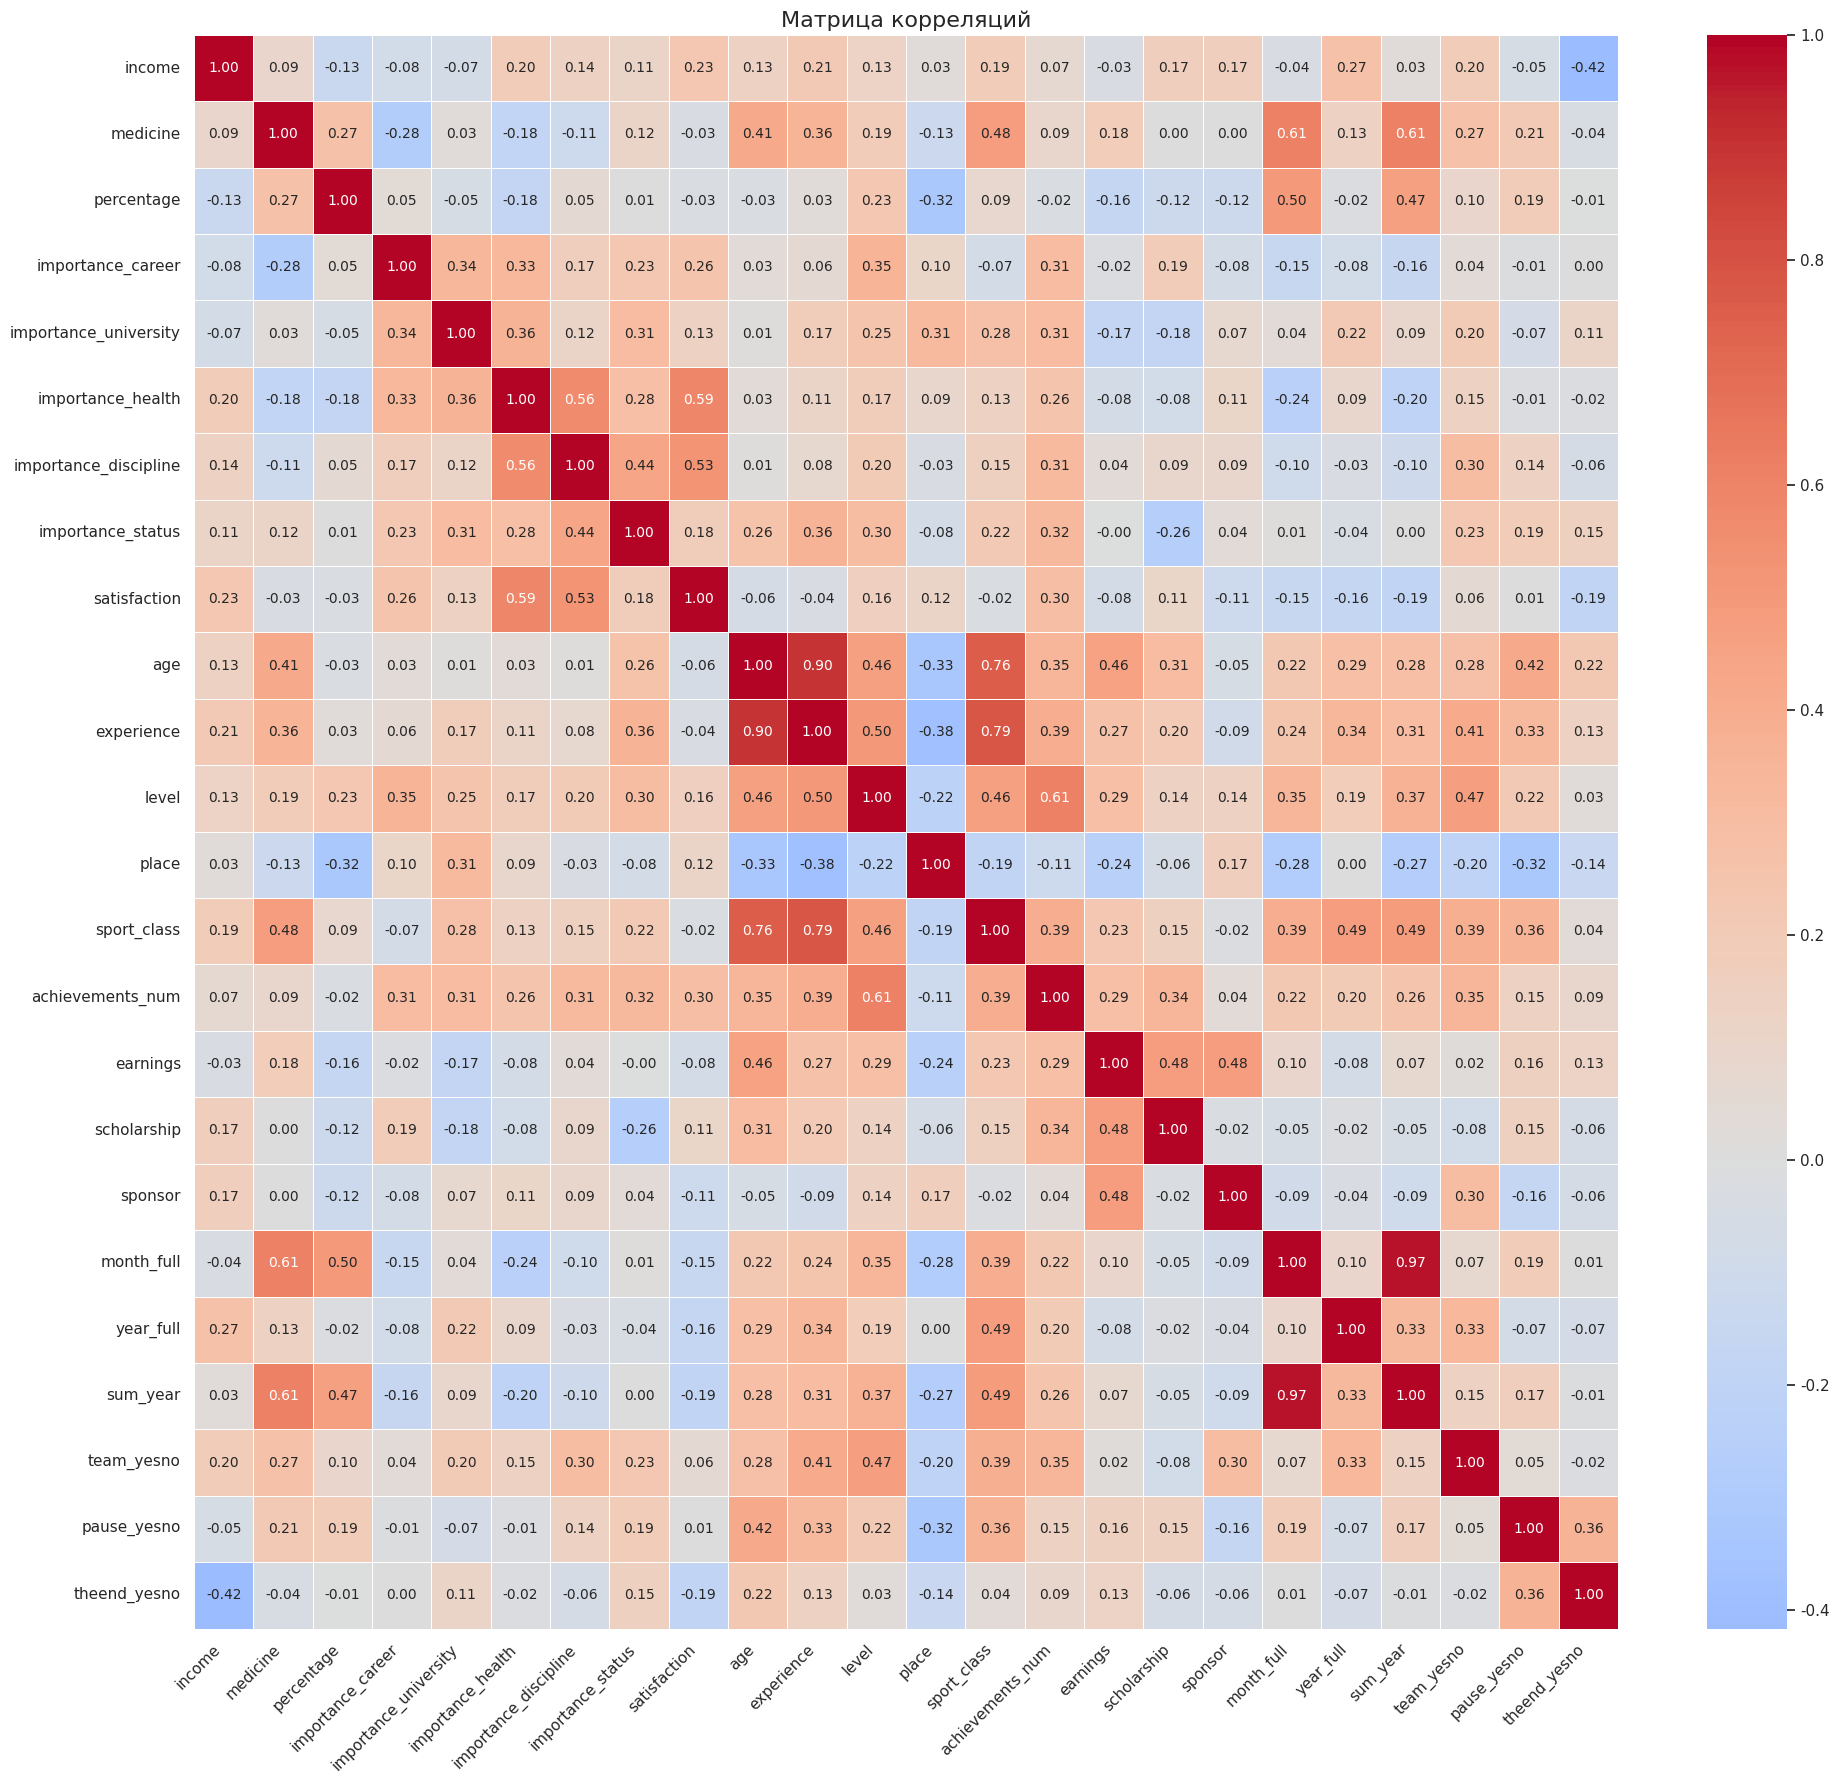

,income,medicine,percentage,importance_career,importance_university,importance_health,importance_discipline,importance_status,satisfaction,age,experience,level,place,sport_class,achievements_num,earnings,scholarship,sponsor,month_full,year_full,sum_year,team_yesno,pause_yesno,theend_yesno
income,1.00,0.09,-0.13,-0.08,-0.07,0.20,0.14,0.11,0.23,0.13,0.21,0.13,0.03,0.19,0.07,-0.03,0.17,0.17,-0.04,0.27,0.03,0.20,-0.05,-0.42
medicine,0.09,1.00,0.27,-0.28,0.03,-0.18,-0.11,0.12,-0.03,0.41,0.36,0.19,-0.13,0.48,0.09,0.18,0.00,0.00,0.61,0.13,0.61,0.27,0.21,-0.04
percentage,-0.13,0.27,1.00,0.05,-0.05,-0.18,0.05,0.01,-0.03,-0.03,0.03,0.23,-0.32,0.09,-0.02,-0.16,-0.12,-0.12,0.50,-0.02,0.47,0.10,0.19,-0.01
importance_career,-0.08,-0.28,0.05,1.00,0.34,0.33,0.17,0.23,0.26,0.03,0.06,0.35,0.10,-0.07,0.31,-0.02,0.19,-0.08,-0.15,-0.08,-0.16,0.04,-0.01,0.00
importance_university,-0.07,0.03,-0.05,0.34,1.00,0.36,0.12,0.31,0.13,0.01,0.17,0.25,0.31,0.28,0.31,-0.17,-0.18,0.07,0.04,0.22,0.09,0.20,-0.07,0.11
importance_health,0.20,-0.18,-0.18,0.33,0.36,1.00,0.56,0.28,0.59,0.03,0.11,0.17,0.09,0.13,0.26,-0.08,-0.08,0.11,-0.24,0.09,-0.20,0.15,-0.01,-0.02
importance_discipline,0.14,-0.11,0.05,0.17,0.12,0.56,1.00,0.44,0.53,0.01,0.08,0.20,-0.03,0.15,0.31,0.04,0.09,0.09,-0.10,-0.03,-0.10,0.30,0.14,-0.06
importance_status,0.11,0.12,0.01,0.23,0.31,0.28,0.44,1.00,0.18,0.26,0.36,0.30,-0.08,0.22,0.32,-0.00,-0.26,0.04,0.01,-0.04,0.00,0.23,0.19,0.15
satisfaction,0.23,-0.03,-0.03,0.26,0.13,0.59,0.53,0.18,1.00,-0.06,-0.04,0.16,0.12,-0.02,0.30,-0.08,0.11,-0.11,-0.15,-0.16,-0.19,0.06,0.01,-0.19
age,0.13,0.41,-0.03,0.03,0.01,0.03,0.01,0.26,-0.06,1.00,0.90,0.46,-0.33,0.76,0.35,0.46,0.31,-0.05,0.22,0.29,0.28,0.28,0.42,0.22


In [ ]:
#матрица
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

file_path = "/content/Данные_курсовая.xlsx"
df = pd.read_excel(file_path)

columns_map = {
    'Что из нижеперечисленного лучше всего описывает финансовое положение вашей семьи: ': "income",
    "Медицина/реабилитация:": "medicine",
    "Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?": "percentage",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): Профессиональная спортивная карьера": "importance_career",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nЛьготы при поступлении в вуз": "importance_university",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nФизическое развитие и здоровье": "importance_health",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nРазвитие дисциплины и характера": "importance_discipline",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nСоциальный статус и престиж": "importance_status",
    "Насколько вы удовлетворены отдачей от финансовых вложений в спорт? Оцените по шкале от 1 – совсем не удовлетворен(а) до 10 – полностью удовлетворен(а). ": "satisfaction",
    "Возраст спортсмена:": "age",
    "Стаж занятий(количество лет занятий художественной гимнастикой):": "experience",
    "Уровень подготовки ": "level",
    "Место занятий": "place",
    "Спортивный разряд": "sport_class",
    " Достижения спортсмена за последние 2 года:": "achievements",
    "Получал ли спортсмен доход от спорта?": "earnings",
    "Выплаты от сборной:": "team_money",
    "Стипендии:": "scholarship",
    "Спонсорская поддержка:": "sponsor",
    "Выплаты за участие в рекламе(связанной со спортом):": "advertising",
    "Доход от работы/подработки тренером/хореографом и т.д.": "job",
    "Общие ежемесячные расходы": "month_full",
    "Общие ежегодные расходы": "year_full",
    "Сумма расходов в год": "sum_year",
    "Состоит ли спортсмен в сборной?": "team_yesno",
    "Были ли случаи прекращения занятий?": "pause_yesno",
    "Прекратил ли спортсмен занятия?": "theend_yesno"
}


data = df.rename(columns=columns_map)
selected_columns = [col for col in columns_map.values() if col in data.columns]
data = data[selected_columns].copy()

# преобразование нужных переменных

# Уровень подготовки
if 'level' in data.columns:
    level_map = {
        'Полупрофессиональный (участие в местных и городских соревнованиях)': 1,
        'Профессиональный (подготовка к соревнованиям всероссийского и высокого уровня)': 2
    }
    data['level'] = data['level'].map(level_map).fillna(0).astype(int)


# Достижения
if 'achievements' in data.columns:
    achievements_map = {
        'Нет достижений': 0,
        'Участие в районных соревнованиях': 1,
        'Призовые места на районных соревнованиях': 2,
        'Участие в городских соревнованиях': 3,
        'Призовые места на городских соревнованиях': 4,
        'Участие во всероссийских соревнованиях': 5,
        'Призовые места на всероссийских соревнованиях': 6,
        'Участие в международных соревнованиях': 7,
        'Призовые места на международных соревнованиях': 8
    }

    # Создаем новую числовую колонку (старую оставляем как есть)
    data['achievements_num'] = data['achievements'].apply(
        lambda x: max([achievements_map.get(a.strip(), 0) for a in str(x).split(', ')]) if pd.notna(x) else 0
    )
    print("Статистика achievements_num:\n", data['achievements_num'].describe())

# Финансовое положение
income_map = {
    'У нас хватает денег только на еду': 1,
    'Мы можем позволить себе еду и одежду, но на более крупные вещи нам приходится экономить': 2,
    'Большинство долгосрочных покупок (холодильник, телевизор) - не проблема, но мы не можем позволить себе купить квартиру': 3
}
data['income'] = data['income'].map(income_map)

# Процент бюджета
percentage_map = {'<5%': 2.5, '5-10%': 7.5, '11-20%': 15.5, '21-30%': 25.5, '>30%': 35}
data['percentage'] = data['percentage'].map(percentage_map)

# Возраст и стаж
age_map = {'4-6 лет': 5, '7-9 лет': 8, '10-12 лет': 11, '13-15 лет': 14, '16 - 18 лет': 17, 'больше 18 лет': 20}
data['age'] = data['age'].map(age_map)

experience_map = {'1-3 года': 2, '4-6 лет': 5, '7-9 лет': 8, '>10 лет': 11}
data['experience'] = data['experience'].map(experience_map)

# Бинарные переменные
binary_map = {'Да': 1, 'Нет': 0}
for col in ['team_yesno', 'pause_yesno', 'theend_yesno']:
    if col in data.columns:
        data[col] = data[col].map(binary_map).fillna(0).astype(int)

# Доход от спорта
if 'earnings' in data.columns:
    earnings_map = {
    'Нет': 0,
    'Да (призовые, стипендии, спонсорская поддержка, работа тренером и т.д.)': 1
    }
    data['earnings'] = data['earnings'].map(earnings_map).fillna(0).astype(int)

# Место занятий
if 'place' in data.columns:
    place_map = {
        'Частный клуб/академия': 1,
        'Районная спортивная школа': 2,
        'Специализированный центр(Например, ЦХГ "Жемчужина")': 3
    }
    data['place'] = data['place'].map(place_map).fillna(0).astype(int)

# Спортивный разряд
if 'sport_class' in data.columns:
    sport_class_map = {
        'Нет': 0,
        'I - III Юношеский': 1,
        'I - III Спортивный(Взрослый)': 2,
        'КМС (кандидат в мастера спорта)': 3,
        'МС (мастер спорта)': 4
    }
    data['sport_class'] = data['sport_class'].map(sport_class_map).fillna(0).astype(int)

# Преобразуем все колонки в числовой формат
for col in data.columns:
    if data[col].dtype not in ['int64', 'float64']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

numeric_cols = [
    'income', 'medicine', 'percentage', 'importance_career', 'importance_university',
    'importance_health', 'importance_discipline', 'importance_status', 'satisfaction',
    'age', 'experience', 'level', 'place', 'sport_class', 'achievements_num',
    'earnings', 'scholarship', 'sponsor', 'month_full', 'year_full', 'sum_year',
    'team_yesno', 'pause_yesno', 'theend_yesno'
]

# Выбираем только существующие колонки
numeric_cols = [col for col in numeric_cols if col in data.columns]
print("Колонки для анализа:", numeric_cols)

# 5. Заполняем пропуски и готовим данные
data_numeric = data[numeric_cols].copy()
data_numeric = data_numeric.fillna(data_numeric.median())  # заполняем пропуски медианой
data_numeric = data_numeric.dropna(how='all')  # удаляем полностью пустые строки

# 6. Расчет корреляции
corr_matrix = data_numeric.corr()

# Визуализация с проверкой
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=.5,
            annot_kws={"size": 10})
plt.title("Матрица корреляций", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(corr_matrix.style.background_gradient(cmap='coolwarm').format("{:.2f}"))

In [ ]:
#регрессия для satisfaction
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import numpy as np

target = 'satisfaction'
cor_target = corr_matrix[target].abs().sort_values(ascending=False)
print("Корреляции с satisfaction:\n", cor_target)

# Оставляем переменные с корреляцией > 0.3
relevant_features = cor_target[(cor_target > 0.3) & (cor_target.index != target)].index.tolist()
print("Отобранные признаки (|corr| > 0.3):", relevant_features)

X = data_numeric[relevant_features].copy()
y = data_numeric[target]

# Удалим мультиколлинеарные признаки по VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Выбор переменных с достаточной корреляцией
target = 'satisfaction'
cor_target = corr_matrix[target].abs().sort_values(ascending=False)
relevant_features = cor_target[(cor_target > 0.3) & (cor_target.index != target)].index.tolist()

X = data_numeric[relevant_features].copy()
y = data_numeric[target]

# VIF цикл — с остановкой, если осталось меньше 2 переменных
while True:
    vif_df = calculate_vif(X)
    max_vif = vif_df["VIF"].max()

    if max_vif <= 15 or X.shape[1] <= 2:
        break

    drop_feature = vif_df.sort_values("VIF", ascending=False).iloc[0]["feature"]
    print(f"Удаляем из-за высокой VIF: {drop_feature}")
    X = X.drop(columns=[drop_feature])

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

Корреляции с satisfaction:
 satisfaction             1.000000
importance_health        0.586606
importance_discipline    0.527608
achievements_num         0.296770
importance_career        0.258502
income                   0.230644
theend_yesno             0.188498
sum_year                 0.185551
importance_status        0.176331
year_full                0.164086
level                    0.161361
month_full               0.154558
importance_university    0.133743
place                    0.116837
sponsor                  0.108735
scholarship              0.106981
earnings                 0.076587
team_yesno               0.064053
age                      0.056160
experience               0.039104
medicine                 0.030924
percentage               0.026119
sport_class              0.024384
pause_yesno              0.005412
Name: satisfaction, dtype: float64
Отобранные признаки (|corr| > 0.3): ['importance_health', 'importance_discipline']
                            OLS Regres

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

# Загрузите данные
df = pd.read_excel("Данные_курсовая.xlsx", sheet_name="Ответы на форму (1)")

# Переименуйте столбцы
df = df.rename(columns={
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nРазвитие дисциплины и характера" : "importance_discipline",
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nФизическое развитие и здоровье" : 'importance_health',
    "Насколько вы удовлетворены отдачей от финансовых вложений в спорт? Оцените по шкале от 1 – совсем не удовлетворен(а) до 10 – полностью удовлетворен(а). ": 'satisfaction'
})

# Отбираем нужные переменные и убираем пропуски
df_model = df[["importance_discipline", 'importance_health', 'satisfaction']].dropna()
df_model = df_model.astype(float)

# Строим модель
model = smf.ols('satisfaction ~ importance_discipline + importance_health', data=df_model).fit()

# Остатки модели
residuals = model.resid

# Тест Шапиро–Уилка
shapiro_test = shapiro(residuals)
print("Шапиро–Уилк:")
print("  Статистика:", shapiro_test.statistic)
print("  p-value:", shapiro_test.pvalue)

# Тест Бройша–Пагана
X = model.model.exog
bp_test = het_breuschpagan(residuals, X)
print("\nБройш–Паган:")
print("  LM статистика:", bp_test[0])
print("  LM p-value:", bp_test[1])
print("  F статистика:", bp_test[2])
print("  F p-value:", bp_test[3])


Шапиро–Уилк:
  Статистика: 0.9520867974306644
  p-value: 0.08285955483357085

Бройш–Паган:
  LM статистика: 3.430967879191013
  LM p-value: 0.179876650213035
  F статистика: 1.7351628728418116
  F p-value: 0.19005392715038832


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

# Загрузите данные
df = pd.read_excel("Данные_курсовая.xlsx", sheet_name="Ответы на форму (1)")

# Переименуйте столбцы
df = df.rename(columns={
    "Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?": "percentage",
    "Место занятий": "place",
    "Спортивный разряд": "sport_class",
    "Сумма расходов в год": "sum_year",
    " Достижения спортсмена за последние 2 года:": "achievements"
})

if 'achievements' in data.columns:
    achievements_map = {
        'Нет достижений': 0,
        'Участие в районных соревнованиях': 1,
        'Призовые места на районных соревнованиях': 2,
        'Участие в городских соревнованиях': 3,
        'Призовые места на городских соревнованиях': 4,
        'Участие во всероссийских соревнованиях': 5,
        'Призовые места на всероссийских соревнованиях': 6,
        'Участие в международных соревнованиях': 7,
        'Призовые места на международных соревнованиях': 8
    }

    # Создаем новую числовую колонку (старую оставляем как есть)
    df['achievements_num'] = df['achievements'].apply(
          lambda x: max([achievements_map.get(a.strip(), 0) for a in str(x).split(', ')]) if pd.notna(x) else 0
    )

percentage_map = {'<5%': 2.5, '5-10%': 7.5, '11-20%': 15.5, '21-30%': 25.5, '>30%': 35}
df['percentage'] = df['percentage'].map(percentage_map)

if 'place' in df.columns:
    place_map = {
        'Частный клуб/академия': 1,
        'Районная спортивная школа': 2,
        'Специализированный центр(Например, ЦХГ "Жемчужина")': 3
    }
    df['place'] = df['place'].map(place_map).fillna(0).astype(int)

# Спортивный разряд
if 'sport_class' in df.columns:
    sport_class_map = {
        'Нет': 0,
        'I - III Юношеский': 1,
        'I - III Спортивный(Взрослый)': 2,
        'КМС (кандидат в мастера спорта)': 3,
        'МС (мастер спорта)': 4
    }
    df['sport_class'] = df['sport_class'].map(sport_class_map).fillna(0).astype(int)

# Отбираем нужные переменные и убираем пропуски
df_model = df[["percentage", "place", "sport_class", "sum_year", 'achievements_num']].dropna()
df_model = df_model.astype(float)

# Строим модель
model = smf.ols('sum_year ~ percentage + place + sport_class + achievements_num', data=df_model).fit()

# Остатки модели
residuals = model.resid

# Тест Шапиро–Уилка
shapiro_test = shapiro(residuals)
print("Шапиро–Уилк:")
print("  Статистика:", shapiro_test.statistic)
print("  p-value:", shapiro_test.pvalue)

# Тест Бройша–Пагана
X = model.model.exog
bp_test = het_breuschpagan(residuals, X)
print("\nБройш–Паган:")
print("  LM статистика:", bp_test[0])
print("  LM p-value:", bp_test[1])
print("  F статистика:", bp_test[2])
print("  F p-value:", bp_test[3])

Шапиро–Уилк:
  Статистика: 0.9569182767613866
  p-value: 0.12260293975554637

Бройш–Паган:
  LM статистика: 3.985119631857403
  LM p-value: 0.4080234343626601
  F статистика: 0.9689637337740878
  F p-value: 0.43644430072336804


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Выбор переменных для модели
model_vars = [
    'sum_year', # Целевая переменная
    'sport_class',
    'percentage',
]
model_data = data_numeric[model_vars].dropna()

# Разделение на предикторы и целевую переменную
X = model_data.drop('sum_year', axis=1)
y = model_data['sum_year']

# Добавление константы
X = sm.add_constant(X)

# Построение модели
model = sm.OLS(y, X).fit()

# Проверка мультиколлинеарности (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Вывод результатов
print(model.summary())
print("\nПроверка мультиколлинеарности:")
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:               sum_year   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     13.65
Date:                Sat, 07 Jun 2025   Prob (F-statistic):           3.41e-05
Time:                        22:33:08   Log-Likelihood:                -583.03
No. Observations:                  41   AIC:                             1172.
Df Residuals:                      38   BIC:                             1177.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.199e+05   1.85e+05     -0.647      

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

# Загрузите данные
df = pd.read_excel("Данные_курсовая.xlsx", sheet_name="Ответы на форму (1)")

# Переименуйте столбцы
df = df.rename(columns={
    "Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?": "percentage",
    "Спортивный разряд": "sport_class",
    "Сумма расходов в год": "sum_year",
})

percentage_map = {'<5%': 2.5, '5-10%': 7.5, '11-20%': 15.5, '21-30%': 25.5, '>30%': 35}
df['percentage'] = df['percentage'].map(percentage_map)

if 'place' in df.columns:
    place_map = {
        'Частный клуб/академия': 1,
        'Районная спортивная школа': 2,
        'Специализированный центр(Например, ЦХГ "Жемчужина")': 3
    }
    df['place'] = df['place'].map(place_map).fillna(0).astype(int)

# Спортивный разряд
if 'sport_class' in df.columns:
    sport_class_map = {
        'Нет': 0,
        'I - III Юношеский': 1,
        'I - III Спортивный(Взрослый)': 2,
        'КМС (кандидат в мастера спорта)': 3,
        'МС (мастер спорта)': 4
    }
    df['sport_class'] = df['sport_class'].map(sport_class_map).fillna(0).astype(int)



# Отбираем нужные переменные и убираем пропуски
df_model = df[["percentage", 'sport_class', 'sum_year']].dropna()
df_model = df_model.astype(float)

# Строим модель
model = smf.ols('sum_year ~ percentage + sport_class', data=df_model).fit()

# Остатки модели
residuals = model.resid

# Тест Шапиро–Уилка
shapiro_test = shapiro(residuals)
print("Шапиро–Уилк:")
print("  Статистика:", shapiro_test.statistic)
print("  p-value:", shapiro_test.pvalue)

# Тест Бройша–Пагана
X = model.model.exog
bp_test = het_breuschpagan(residuals, X)
print("\nБройш–Паган:")
print("  LM статистика:", bp_test[0])
print("  LM p-value:", bp_test[1])
print("  F статистика:", bp_test[2])
print("  F p-value:", bp_test[3])


Шапиро–Уилк:
  Статистика: 0.9717462307124843
  p-value: 0.3924463212583506

Бройш–Паган:
  LM статистика: 2.7470350954990046
  LM p-value: 0.2532146963982262
  F статистика: 1.3644345463098926
  F p-value: 0.26775874308900816


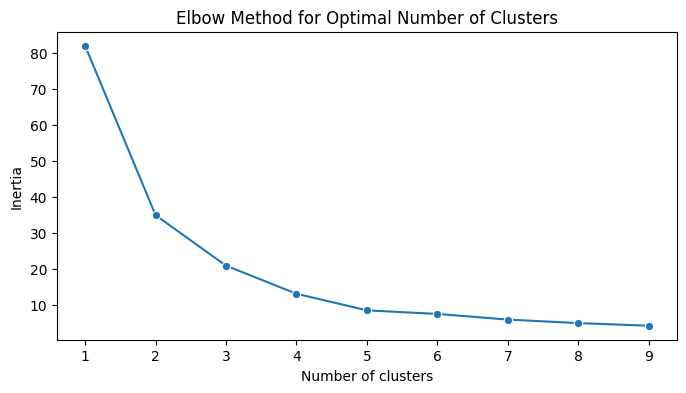

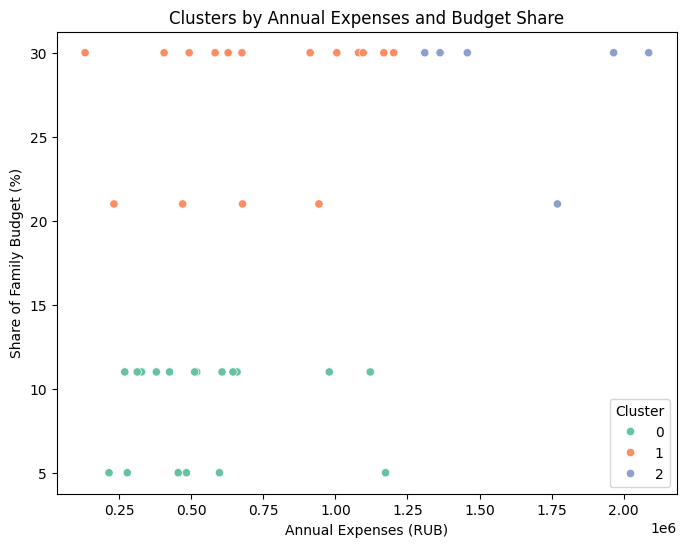

ANOVA Result:
F-statistic: 0.155
P-value: 0.857


In [ ]:
#ANOVA(расходы в год, %бюджета)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузите данные
df = pd.read_excel("Данные_курсовая.xlsx", sheet_name="Ответы на форму (1)")

# Переименование нужных столбцов
df = df.rename(columns={
    'Сумма расходов в год': 'sum_year',
    'Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?': 'percentage',
    'Насколько вы удовлетворены отдачей от финансовых вложений в спорт? Оцените по шкале от 1 – совсем не удовлетворен(а) до 10 – полностью удовлетворен(а). ': 'satisfaction'
})

# Оставляем нужные переменные
data = df[['sum_year', 'percentage', 'satisfaction']].copy()

# Очистка и преобразование столбца 'percentage'
data['percentage'] = (
    data['percentage']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.replace('<', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.extract('(\d+\.?\d*)')[0]
    .astype(float)
)

# Удаляем пропуски
data = data.dropna()

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[['sum_year', 'percentage']])

# Метод локтя для определения оптимального числа кластеров
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Визуализация метода локтя
plt.figure(figsize=(8, 4))
sns.lineplot(x=range(1, 10), y=inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

# Выбираем число кластеров на основе графика 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
data['cluster'] = kmeans.fit_predict(X_scaled)

# Визуализация кластеров
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='sum_year', y='percentage', hue='cluster', palette='Set2')
plt.title("Clusters by Annual Expenses and Budget Share")
plt.xlabel("Annual Expenses (RUB)")
plt.ylabel("Share of Family Budget (%)")
plt.legend(title="Cluster")
plt.show()

# ANOVA — сравнение удовлетворённости между кластерами
groups = [group['satisfaction'].values for name, group in data.groupby('cluster')]
anova_result = f_oneway(*groups)

print("ANOVA Result:")
print(f"F-statistic: {anova_result.statistic:.3f}")
print(f"P-value: {anova_result.pvalue:.3f}")


In [ ]:
# Выберем финансовые переменные, которые точно есть в данных
financial_cols = ['sum_year', 'year_full', 'month_full']
financial_df = df[financial_cols].dropna()

# 1. Матрица корреляции
correlation_matrix = financial_df.corr()
print("Матрица корреляции между финансовыми переменными:")
print(correlation_matrix)

# 2. Расчет VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = financial_cols
vif_data["VIF"] = [variance_inflation_factor(financial_df.values, i) for i in range(len(financial_cols))]

print("\nVIF для финансовых переменных:")
print(vif_data)

Матрица корреляции между финансовыми переменными:
            sum_year  year_full  month_full
sum_year    1.000000   0.328514    0.971779
year_full   0.328514   1.000000    0.096444
month_full  0.971779   0.096444    1.000000

VIF для финансовых переменных:
     Variable  VIF
0    sum_year  inf
1   year_full  inf
2  month_full  inf


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
# Удаляем линейно зависимые переменные
financial_cols = ['sum_year']  # Оставляем только одну переменную
financial_df = df[financial_cols].dropna()

# Добавляем константу для VIF (требуется statsmodels)
import statsmodels.api as sm
X = sm.add_constant(financial_df)

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = financial_cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i + 1) for i in range(len(financial_cols))]

print("VIF после исключения зависимых переменных:")
print(vif_data)

VIF после исключения зависимых переменных:
   Variable  VIF
0  sum_year  1.0


In [ ]:
import numpy as np
import pandas as pd

file_path = "/content/Данные_курсовая.xlsx"
df = pd.read_excel(file_path)

df = df.rename(columns={
    'Что из нижеперечисленного лучше всего описывает финансовое положение вашей семьи: ': 'income',
    "Медицина/реабилитация:": 'medicine',
    "Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?": 'percentage',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): Профессиональная спортивная карьера": 'importance_career',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nЛьготы при поступлении в вуз": 'importance_university',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nФизическое развитие и здоровье": 'importance_health',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nРазвитие дисциплины и характера": 'importance_discipline',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nСоциальный статус и престиж": 'importance_status',
    "Насколько вы удовлетворены отдачей от финансовых вложений в спорт? Оцените по шкале от 1 – совсем не удовлетворен(а) до 10 – полностью удовлетворен(а). ": 'satisfaction',
    "Возраст спортсмена:": 'age',
    "Стаж занятий(количество лет занятий художественной гимнастикой):": 'experience',
    "Уровень подготовки ": 'level',
    "Место занятий": 'place',
    "Спортивный разряд": 'sport_class',
    " Достижения спортсмена за последние 2 года:": 'achievements',
    "Получал ли спортсмен доход от спорта?": 'earnings',
    "Выплаты от сборной: ": 'team_money',
    "Стипендии:": 'scholarship',
    "Спонсорская поддержка:": 'sponsor',
    "Выплаты за участие в рекламе(связанной со спортом): ": 'advertising',
    " Доход от работы/подработки тренером/хореографом и т.д.": 'job',
    "Общие ежемесячные расходы": 'month_full',
    "Общие ежегодные расходы": 'year_full',
    "Сумма расходов в год": 'sum_year',
    "Состоит ли спортсмен в сборной?": 'team_yesno',
    "Были ли случаи прекращения занятий?": 'pause_yesno',
    "Прекратил ли спортсмен занятия?": 'theend_yesno'
})

income_map = {
    'У нас хватает денег только на еду': 1,
    'Мы можем позволить себе еду и одежду, но на более крупные вещи нам приходится экономить': 2,
    'Большинство долгосрочных покупок (холодильник, телевизор) - не проблема, но мы не можем позволить себе купить квартиру': 3
}
df['income'] = df['income'].map(income_map)

percentage_map = {'<5%': 2.5, '5-10%': 7.5, '11-20%': 15.5, '21-30%': 25.5, '>30%': 35}
df['percentage'] = df['percentage'].map(percentage_map)

# Select relevant financial columns for variation analysis
financial_cols = ['income', 'percentage', 'month_full', 'year_full', 'sum_year'
]

# Convert to numeric (in case some data is misformatted)
df_financial = df[financial_cols].apply(pd.to_numeric, errors='coerce')

# Calculate basic statistics
variation_stats = df_financial.describe().T

# Add Coefficient of Variation (CV = std / mean)
variation_stats['CV'] = variation_stats['std'] / variation_stats['mean']

variation_stats[['mean', 'std', 'min', 'max', 'CV']]


,mean,std,min,max,CV
income,2.317073,0.649578,1.0,3.0,0.280344
percentage,23.865854,11.257233,2.5,35.0,0.471688
month_full,54417.073171,38062.106500,3500.0,156800.0,0.699452
year_full,144609.756098,114073.359740,32000.0,550000.0,0.788836
sum_year,797614.634146,481330.379553,132000.0,2086600.0,0.603462


In [ ]:
import pandas as pd
file_path = "/content/Данные_курсовая.xlsx"

df = pd.read_excel(file_path)

df = df.rename(columns={
    'Что из нижеперечисленного лучше всего описывает финансовое положение вашей семьи: ': 'income',
    "Медицина/реабилитация:": 'medicine',
    "Какой процент от семейного бюджета вкладывается в гимнастику(на одного ребенка)?": 'percentage',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): Профессиональная спортивная карьера": 'importance_career',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nЛьготы при поступлении в вуз": 'importance_university',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nФизическое развитие и здоровье": 'importance_health',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nРазвитие дисциплины и характера": 'importance_discipline',
    "Оцените по шкале от 1 (совсем не важно) до 5 (крайне важно): \nСоциальный статус и престиж": 'importance_status',
    "Насколько вы удовлетворены отдачей от финансовых вложений в спорт? Оцените по шкале от 1 – совсем не удовлетворен(а) до 10 – полностью удовлетворен(а). ": 'satisfaction',
    "Возраст спортсмена:": 'age',
    "Стаж занятий(количество лет занятий художественной гимнастикой):": 'experience',
    "Уровень подготовки ": 'level',
    "Место занятий": 'place',
    "Спортивный разряд": 'sport_class',
    " Достижения спортсмена за последние 2 года:": 'achievements',
    "Получал ли спортсмен доход от спорта?": 'earnings',
    "Выплаты от сборной: ": 'team_money',
    "Стипендии:": 'scholarship',
    "Спонсорская поддержка:": 'sponsor',
    "Выплаты за участие в рекламе(связанной со спортом): ": 'advertising',
    " Доход от работы/подработки тренером/хореографом и т.д.": 'job',
    "Общие ежемесячные расходы": 'month_full',
    "Общие ежегодные расходы": 'year_full',
    "Сумма расходов в год": 'sum_year',
    "Состоит ли спортсмен в сборной?": 'team_yesno',
    "Были ли случаи прекращения занятий из-за:(отметьте все подходящие)": 'pause_reason',
    "Прекратил ли спортсмен занятия?": 'theend_yesno',
    "Сталкивались ли Вы со следующими проблемами в спорте? (отметьте все подходящие)": 'problems',
    "Если спортсмен прекратил занятия, укажите основную причину:": 'theend_reason'
})

df.columns = df.columns.str.strip()

# Re-run the percentage calculations with corrected column names
fin_difficulty_col = 'problems'
disruption_col = 'pause_reason'
stopped_col = 'theend_reason'

# Total number of responses
total_respondents = len(df)

# 1. % facing financial difficulties
financial_difficulties = df[fin_difficulty_col].dropna().str.contains("Финансовые трудности", case=False)
percent_financial_difficulties = financial_difficulties.sum() / total_respondents * 100

# 2. % paused due to financial difficulties
paused_due_to_finances = df[disruption_col].dropna().str.contains("Финансовых трудностей", case=False)
percent_paused_financial = paused_due_to_finances.sum() / total_respondents * 100

# 3. % who stopped completely
stopped= df[stopped_col].dropna().str.contains("Финансовые трудности", case=False)
percent_stopped = stopped.sum() / total_respondents * 100

percent_financial_difficulties, percent_paused_financial, percent_stopped



(np.float64(63.41463414634146), np.float64(7.317073170731707), np.float64(0.0))